# Pipeline for classification. 
### 1. MOMENT (0.3B, large) is used for the embeddings
### 2. PCA to reduce dimensionality of moment's embedding (to like 50/100 features) (OPTIONAL) --> better without
### 3. TabPFN: concat the PCA output with metadata and use TabPFN for the classification   

## Import

In [1]:
import os
import sys
import warnings
from pathlib import Path
import numpy as np
import torch

warnings.filterwarnings("ignore")

# --- Project Root Setup ---
def find_project_root(name='Bambino', start=None):
    if start is None: start = os.getcwd()
    parent_dir = start
    while True:
        if os.path.basename(parent_dir) == name:
            return parent_dir
        new_parent = os.path.dirname(parent_dir)
        if new_parent == parent_dir: return None
        parent_dir = new_parent

PROJECT_ROOT = find_project_root('Bambino')
if PROJECT_ROOT:
    sys.path.append(PROJECT_ROOT)
    print(f"Project root added: {PROJECT_ROOT}")
else:
    print("Project root not found!")

# --- Import Project Modules ---
from config import settings
# Ensure config_baseline exists or define dataset_type manually
try:
    import config_moment as cfg
    DATASET_TYPE = cfg.dataset_type
except ImportError:
    print("config_moment.py not found, using default dataset type.")
    DATASET_TYPE = 'normalized' # Default fallback

SPECIFY_DATASET_OVERRIDE = True
if SPECIFY_DATASET_OVERRIDE:
    DATASET_TYPE = 'augmented_normalized'  # or 'augmented_normalized', 'normalized', etc.

from DataUtils.BoaOpenFaceDataset import BoaOpenFaceDataset

# --- Import Local Utils ---
# Add current directory to path so we can import the .py files we just made
sys.path.append(os.getcwd())
from feature_extraction import MomentEmbedder
from pipeline_pca_tabpfn import HybridPipeline

print(f"Configuration: Dataset Type = {DATASET_TYPE}")
print(f"GPU Available: {torch.cuda.is_available()}")

Project root added: /home/phd2/Scrivania/CorsoRepo/Bambino
Configuration: Dataset Type = augmented_normalized
GPU Available: True


## Load Data

In [2]:
# Define paths
TRAIN_PATH = settings.get_dataset_path(DATASET_TYPE, settings.training_filename)
VAL_PATH = settings.get_dataset_path(DATASET_TYPE, settings.validation_filename)
TEST_PATH = settings.get_dataset_path(DATASET_TYPE, settings.test_filename)

# Load Datasets
# IMPORTANT: We load Train first to establish the master audio list
print("Loading Training Set...")
train_ds = BoaOpenFaceDataset.load_dataset(TRAIN_PATH)
audio_master_list = train_ds.audio_groups  # This is our source of truth

print(f"Loading Validation Set (forcing audio groups)...")
val_ds = BoaOpenFaceDataset.load_dataset(VAL_PATH, audio_groups=audio_master_list)

print(f"Loading Test Set (forcing audio groups)...")
test_ds = BoaOpenFaceDataset.load_dataset(TEST_PATH, audio_groups=audio_master_list)

print(f"\nCounts: Train={len(train_ds)}, Val={len(val_ds)}, Test={len(test_ds)}")

Loading Training Set...
Loading Validation Set (forcing audio groups)...
Loading Test Set (forcing audio groups)...

Counts: Train=1970, Val=140, Test=137


# MOMENT feature extraction

In [3]:
# Initialize MOMENT Wrapper
# Using 'large' model for best embeddings. Ensure you have ~16GB VRAM or use 'base'/'small'
embedder = MomentEmbedder(model_name="AutonLab/MOMENT-1-large")

# Extract Embeddings (Time Series only)
print("\n--- Extracting Train Embeddings ---")
train_emb = embedder.get_embeddings(train_ds)

print("\n--- Extracting Val Embeddings ---")
val_emb = embedder.get_embeddings(val_ds)

print("\n--- Extracting Test Embeddings ---")
test_emb = embedder.get_embeddings(test_ds)

print(f"\nRaw Embedding Shape: {train_emb.shape}")


"""
N.B.: NO PRE-TRAINING MOMENT ON THE DATASET
Why?
1. Data Volume: Foundation models like MOMENT are pre-trained on millions/billions of samples. 
    Our dataset (a lot under <10,000 samples) is too small. 
    Running pre-training on such a small set will likely cause the model to "forget" the robust general features it already knows (Catastrophic Forgetting) 
    and overfit to the noise in your specific files.

2. Nature of Data: Our data (gaze vectors, head position) represents physical motion. 
    MOMENT is already excellent at understanding motion dynamics. 
    We don't need to teach it how things move, 
    we just need it to describe the movement (Embeddings) so TabPFN can classify it.
""";

Loading MOMENT model: AutonLab/MOMENT-1-large on cuda...

--- Extracting Train Embeddings ---
Extracting embeddings for 1970 samples...


100%|██████████| 124/124 [01:23<00:00,  1.49it/s]



--- Extracting Val Embeddings ---
Extracting embeddings for 140 samples...


100%|██████████| 9/9 [00:05<00:00,  1.51it/s]



--- Extracting Test Embeddings ---
Extracting embeddings for 137 samples...


100%|██████████| 9/9 [00:05<00:00,  1.51it/s]


Raw Embedding Shape: (1970, 1024)


## Pipeline init and metadata processing

In [6]:
# Initialize Pipeline (PCA + TabPFN)
# We choose n components. TabPFN works best with < 100 features total.
n_metadata = 3
n_feat_after_pca = 100 - n_metadata  # Reserve 2 for metadata
pipeline = HybridPipeline(n_pca_components=n_feat_after_pca)

# Process Metadata (Age, Sex, Audio)
# Returns numpy arrays
print("Processing Metadata...")
meta_train = pipeline.process_metadata(train_ds, fit_scaler=True) # Fit scaler on train
meta_val   = pipeline.process_metadata(val_ds, fit_scaler=False)
meta_test  = pipeline.process_metadata(test_ds, fit_scaler=False)

# Get Labels
y_train = np.array([inst.trial_type for inst in train_ds.instances])
y_val   = np.array([inst.trial_type for inst in val_ds.instances])
y_test  = np.array([inst.trial_type for inst in test_ds.instances])

print(f"Metadata shape: {meta_train.shape}")

Processing Metadata...
Metadata shape: (1970, 3)


## Dim reduction with PCA

In [7]:
# Reduce MOMENT embeddings via PCA
print("Reducing Embeddings with PCA...")
pca_train = pipeline.fit_transform_pca(train_emb)
pca_val   = pipeline.transform_pca(val_emb)
pca_test  = pipeline.transform_pca(test_emb)

print(f"Reduced Embedding Shape: {pca_train.shape}")

Reducing Embeddings with PCA...
Fitting PCA to reduce dim from 1024 to 97...
PCA Explained Variance: 0.9511
Reduced Embedding Shape: (1970, 97)


## Feature fusion

In [8]:
# Concatenate: [Metadata, PCA_Embeddings]
# Axis 1 = features
pca_embeddings = False
if pca_embeddings:
    print("Concatenating Metadata and PCA Embeddings...")
    print(f"meta shape: {meta_train.shape}, pca train shape: {pca_train.shape}")
    X_train = np.hstack([meta_train, pca_train])
    X_val   = np.hstack([meta_val, pca_val])
    X_test  = np.hstack([meta_test, pca_test])
else:
    # concat metadata with embeddings directly
    print("Concatenating Metadata and Raw Embeddings...")
    print(f"meta shape: {meta_train.shape}, train emb shape: {train_emb.shape}")
    X_train = np.hstack([meta_train, train_emb])
    X_val   = np.hstack([meta_val, val_emb])
    X_test  = np.hstack([meta_test, test_emb])

print(f"Final Feature Matrix Shape: {X_train.shape}")
print(f"Final Feature Matrix Shape: {X_val.shape}")
print(f"Final Feature Matrix Shape: {X_test.shape}")

Concatenating Metadata and Raw Embeddings...
meta shape: (1970, 3), train emb shape: (1970, 1024)
Final Feature Matrix Shape: (1970, 1027)
Final Feature Matrix Shape: (140, 1027)
Final Feature Matrix Shape: (137, 1027)


## TabPFN Training & Evaluation

Training TabPFN on 1970 samples with 1027 features...

Running Validation...
--- Validation Results ---
              precision    recall  f1-score   support

           0       0.17      0.14      0.15        28
           1       0.79      0.82      0.81       112

    accuracy                           0.69       140
   macro avg       0.48      0.48      0.48       140
weighted avg       0.67      0.69      0.68       140

Balanced Acc: 0.4821
F1 Macro: 0.4804


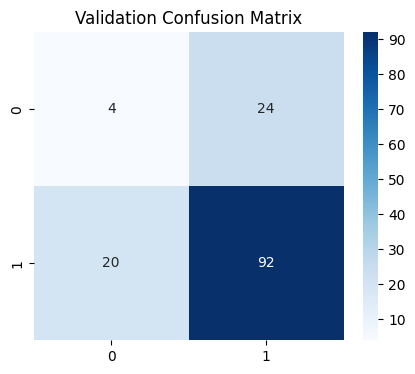


Running Test...
--- Test Results ---
              precision    recall  f1-score   support

           0       0.14      0.11      0.12        27
           1       0.79      0.83      0.81       110

    accuracy                           0.69       137
   macro avg       0.46      0.47      0.47       137
weighted avg       0.66      0.69      0.67       137

Balanced Acc: 0.4692
F1 Macro: 0.4657


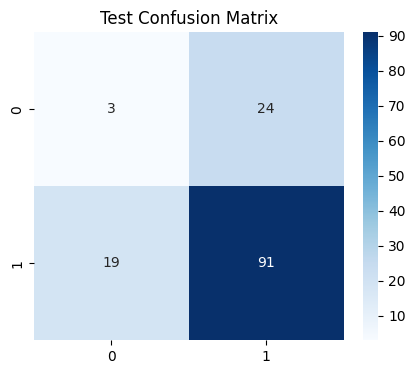

In [9]:
# Train TabPFN
# Note: TabPFN effectively "trains" in a single forward pass, but .fit() stores the support set.
pipeline.train_tabpfn(X_train, y_train)

# Evaluate on Validation
print("\nRunning Validation...")
preds_val, probs_val = pipeline.evaluate(X_val, y_val, split_name="Validation")

# Evaluate on Test
print("\nRunning Test...")
preds_test, probs_test = pipeline.evaluate(X_test, y_test, split_name="Test")

## Save results

In [8]:
# Save predictions for ensemble or analysis
import pandas as pd

results_df = pd.DataFrame({
    'pt_id': [inst.pt_id for inst in test_ds.instances],
    'true_label': y_test,
    'pred_label': preds_test,
    'prob_class_1': probs_test[:, 1]
})

out_file = Path("moment_tabpfn_results.csv")
results_df.to_csv(out_file, index=False)
print(f"Saved predictions to {out_file}")

Saved predictions to moment_tabpfn_results.csv
